1. Using `GridSearchCV` (introduced conceptually in week 3), search over `max_depth in [2, 4, 6, 8, None]` and `min_samples_split in [2, 10, 30]` for `DecisionTreeClassifier` on the training data, with `cv=5`. Which combination wins, and how does its test accuracy compare to notebook 1's baseline `max_depth=8` tree?

In [3]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

data=load_digits(as_frame=True)
df=data.frame

x = df.drop(columns="target")
y = df["target"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
tree_model=DecisionTreeClassifier(random_state=42)

parametr={"max_depth":[2, 4, 6, 8,None],
          "min_samples_split":[2, 10, 30]}

grid=GridSearchCV(tree_model,parametr,cv=5)
grid.fit(x_train,y_train)
y_pred_grid=grid.predict(x_test)
grid.best_params_

{'max_depth': None, 'min_samples_split': 2}

In [5]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred_grid)

0.825

2. Repeat notebook 1's `n_estimators` sweep (section 3.2) for Random Forest, but this time also track **fit time** (`%timeit` or `time.perf_counter()`). At what point does more accuracy stop being worth the extra training time?


In [14]:
from sklearn.ensemble import RandomForestClassifier
import time
n_estimators=[1, 5, 10, 20, 50, 100, 200, 400]
acc_forest=[]
fit_time=[]
for n in n_estimators:
    start=time.perf_counter()
    forest_model=RandomForestClassifier(n_estimators=n,random_state=42).fit(x_train,y_train)
    end=time.perf_counter()
    fit_time.append(end-start)
    y_pred_forest=forest_model.predict(x_test)
    acc_forest.append(accuracy_score(y_test,y_pred_forest))

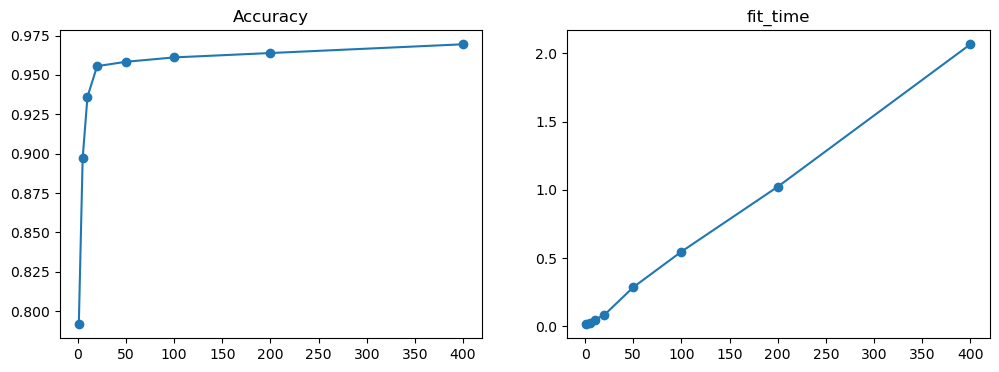

In [24]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,2,figsize=(12, 4))
ax[0].plot(n_estimators,acc_forest,marker="o")
ax[0].set_title("Accuracy")

ax[1].plot(n_estimators,fit_time,marker="o")
ax[1].set_title("fit_time")
plt.show()

3. Notebook 2's Gradient Boosting (section 2.3) used the default `learning_rate=0.1`. Try `learning_rate` values `[0.01, 0.05, 0.1, 0.3, 1.0]` at a fixed `n_estimators=100`, and plot test accuracy against `learning_rate`. Is there a clear best value?

In [26]:
from sklearn.ensemble import GradientBoostingClassifier

rate_values=[0.01, 0.05, 0.1, 0.3, 1.0]
acc_gb=[]

for rate in rate_values:
    gb_model=GradientBoostingClassifier(learning_rate=rate,n_estimators=100,random_state=42).fit(x_train,y_train)
    acc_gb.append(accuracy_score(y_test,gb_model.predict(x_test)))
acc_gb    

[0.8916666666666667,
 0.9472222222222222,
 0.9555555555555556,
 0.9722222222222222,
 0.9527777777777777]

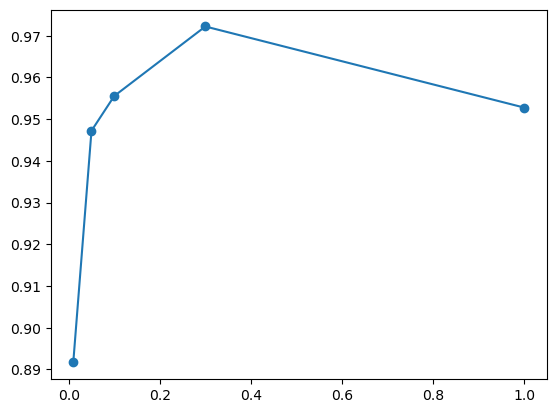

In [27]:
plt.plot(rate_values,acc_gb,marker="o")
plt.show()

4. Train an `SVC(kernel="poly", degree=3)` on the moons dataset and add it as a fourth panel next to notebook 3's linear/RBF comparison (section 2.3). Where does its boundary fall between the two?


In [28]:
from sklearn.datasets import make_moons
import numpy as np

X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42)

def plot_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], alpha=0.35)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="white", linewidths=0.6, s=26)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

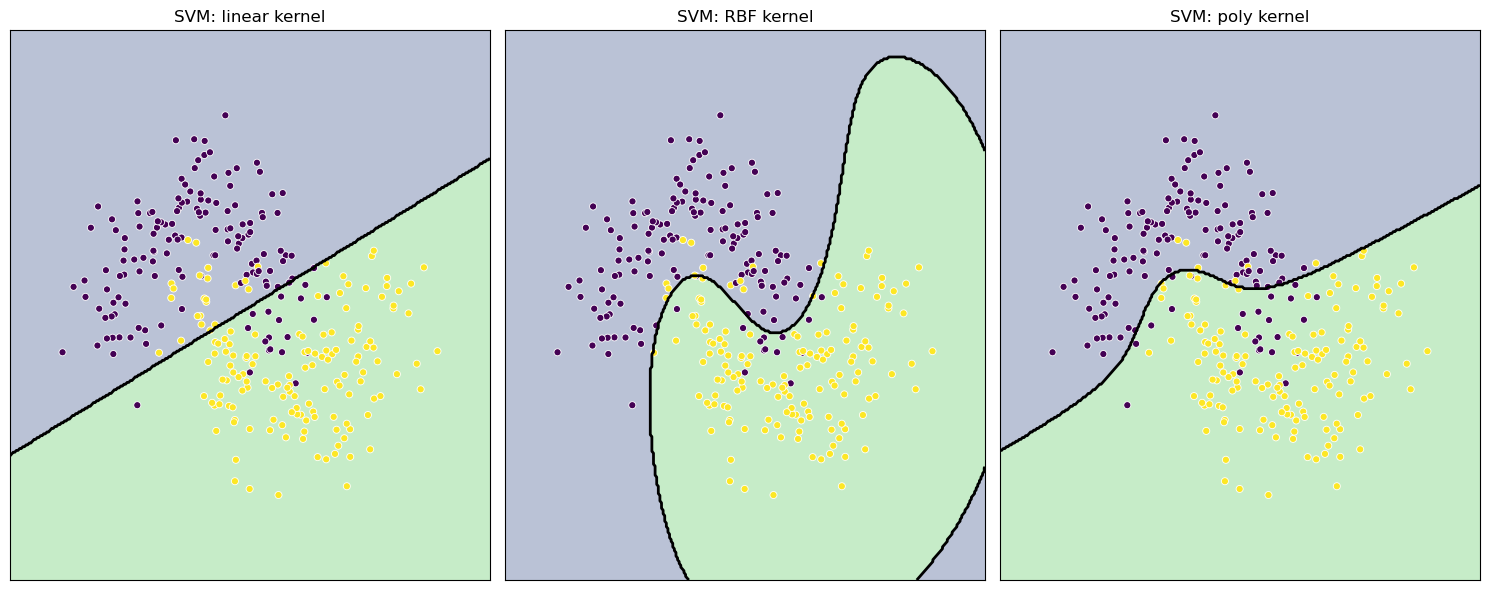

In [33]:
from sklearn.svm import SVC

svm_rbf_moons = SVC(kernel="rbf", C=1, gamma="scale").fit(X_moons, y_moons)
svm_linear_moons = SVC(kernel="linear", C=1).fit(X_moons, y_moons)
svm_poly_moons = SVC(kernel="poly", C=1).fit(X_moons, y_moons)


fig, axes = plt.subplots(1, 3, figsize=(15, 6))
plot_boundary(axes[0], svm_linear_moons, X_moons, y_moons, "SVM: linear kernel")
plot_boundary(axes[1], svm_rbf_moons, X_moons, y_moons, "SVM: RBF kernel")
plot_boundary(axes[2], svm_poly_moons, X_moons, y_moons, "SVM: poly kernel")

plt.tight_layout()
plt.show()

5. Compare `GaussianNB`'s test accuracy, precision, and recall (notebook 4, `average="macro"`) against Random Forest's (notebook 1). How large is the gap on this image dataset? Would you expect it to be larger or smaller on a text-classification dataset, and why?


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,precision_score,recall_score

nb = GaussianNB()
nb.fit(x_train, y_train)

y_pred_nb = nb.predict(x_test)

In [36]:
print(f"Naive Bayes test accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Naive Bayes test recall: {recall_score(y_test, y_pred_nb,average="macro"):.4f}")
print(f"Naive Bayes test precision: {precision_score(y_test, y_pred_nb,average="macro"):.4f}")

Naive Bayes test accuracy: 0.8111
Naive Bayes test recall: 0.8103
Naive Bayes test precision: 0.8463


6. **Bringing it all together.** This week's digits dataset already showed all eight models handle a 10-class image problem without any code changes. Now check the opposite direction: a small, non-image, tabular dataset. Load `sklearn.datasets.load_wine(as_frame=True)` (13 chemical features, 3 classes) from week 4's final exercise, split with `stratify`, scale, fit all eight models from section 2 above with no changes beyond swapping the dataset in, and report test accuracy for each. Write two sentences on which model you'd pick for this dataset and why.

In [38]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

data=load_wine(as_frame=True)
df=data.frame

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

scale=StandardScaler()

x_train_scaled=scale.fit_transform(x_train)
x_test_scaled=scale.fit_transform(x_test)

In [ ]:
#...................